**CREDIT RISK PREDICTION MODEL**

**STEP 01:** IMPORTING LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

**STEP 02:** LOADING THE DATA

In [4]:
loan_data = pd.read_csv("/content/loan-prediction-dataset.csv")
loan_data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


**STEP 03:** EDA

In [5]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
# CHEKING MISSING VALUES
loan_data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [7]:
# REPLACING 3+ WITH 3 AND CONVERTING THE DEPENDENTS COLUMN INTO NUMERIC
loan_data['Dependents']= loan_data['Dependents'].replace('3+', '3')
loan_data['Dependents'] = pd.to_numeric(loan_data['Dependents'])

In [8]:
# HANDLING THE MISSING VALUES FOR THE FOLLOWING COLUMN USING MODE AND MEDIAN, MODE FOR CATEGORICAL COLUMN AND MEDIAN FOR NUMERIC COLUMN
loan_data['Gender'].fillna(loan_data['Gender'].mode()[0], inplace=True)
loan_data['Married'].fillna(loan_data['Married'].mode()[0], inplace=True)
loan_data['Self_Employed'].fillna(loan_data['Self_Employed'].mode()[0], inplace=True)

/tmp/ipython-input-215/714227071.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data['Gender'].fillna(loan_data['Gender'].mode()[0], inplace=True)
/tmp/ipython-input-215/714227071.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [9]:
loan_data['Dependents'].fillna(loan_data['Dependents'].median(), inplace=True)
loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].median(), inplace=True)
loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].median(), inplace=True)
loan_data['Credit_History'].fillna(loan_data['Credit_History'].median(), inplace=True)

/tmp/ipython-input-215/1432863160.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data['Dependents'].fillna(loan_data['Dependents'].median(), inplace=True)
/tmp/ipython-input-215/1432863160.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

In [10]:
loan_data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [11]:
loan_data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2.0,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0.0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3.0,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2.0,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1.0,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [12]:
# converting text to numeric
loan_data['Gender']= loan_data['Gender'].replace({'Male': 0, 'Female': 1})
loan_data['Married']= loan_data['Married'].replace({'Yes': 0, 'No': 1})
loan_data['Education']= loan_data['Education'].replace({'Graduate': 0, 'Not Graduate': 1})
loan_data['Self_Employed']= loan_data['Self_Employed'].replace({'Yes': 0, 'No': 1})
loan_data['Property_Area']= loan_data['Property_Area'].replace({'Urban': 0, 'Rural': 1, 'Semiurban': 2})

/tmp/ipython-input-215/3026737787.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data['Gender']= loan_data['Gender'].replace({'Male': 0, 'Female': 1})
/tmp/ipython-input-215/3026737787.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data['Married']= loan_data['Married'].replace({'Yes': 0, 'No': 1})
/tmp/ipython-input-215/3026737787.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=Fa

**VISUALIZATION**

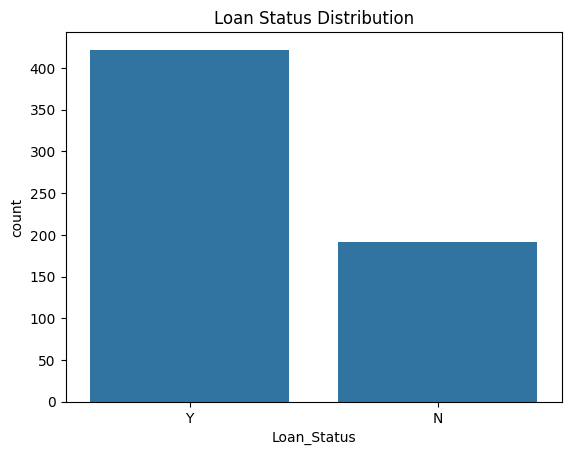

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Loan_Status', data=loan_data)
plt.title("Loan Status Distribution")
plt.show()

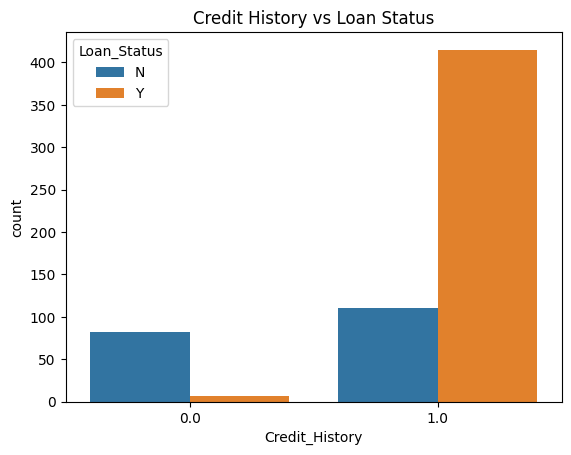

In [14]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=loan_data)
plt.title("Credit History vs Loan Status")
plt.show()

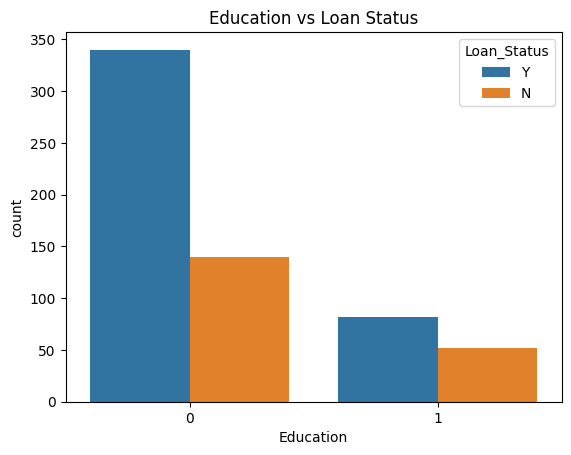

In [15]:
sns.countplot(x='Education', hue='Loan_Status', data=loan_data)
plt.title("Education vs Loan Status")
plt.show()

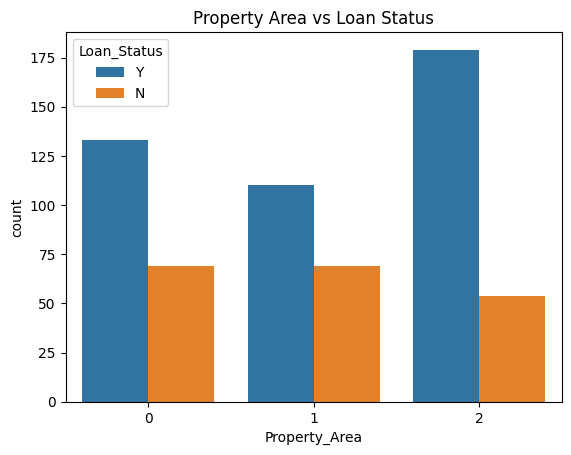

In [16]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=loan_data)
plt.title("Property Area vs Loan Status")
plt.show()

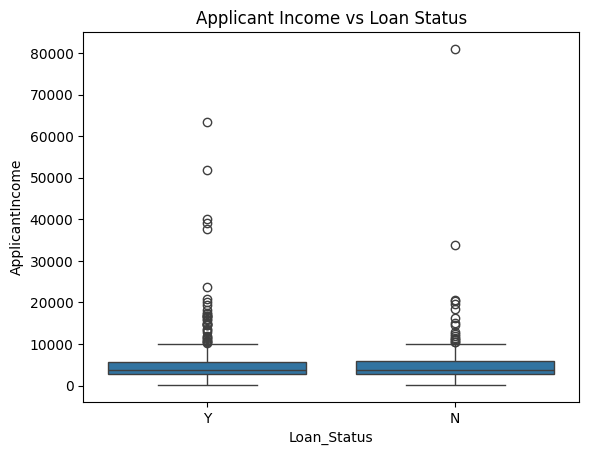

In [17]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=loan_data)
plt.title("Applicant Income vs Loan Status")
plt.show()

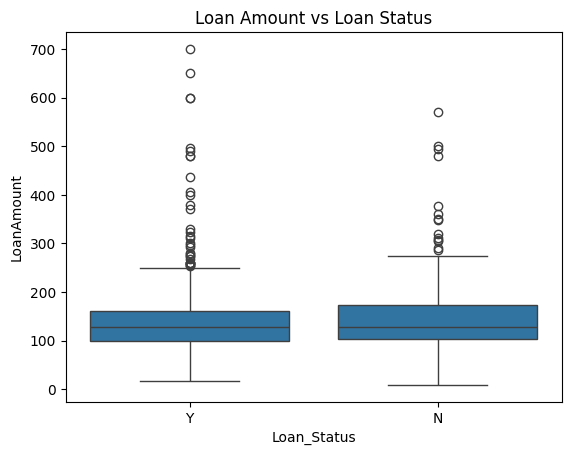

In [18]:
sns.boxplot(x='Loan_Status', y='LoanAmount', data=loan_data)
plt.title("Loan Amount vs Loan Status")
plt.show()

----- Logistic Regression -----
Accuracy: 0.79
Confusion Matrix:
[[18 25]
 [ 1 79]]


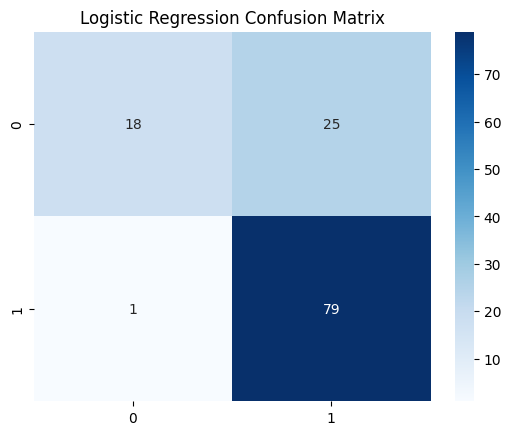

In [20]:
# SETTING X AND Y FEATURES
X = loan_data[['Credit_History','ApplicantIncome', 'LoanAmount',
             'Self_Employed',]]
y = loan_data['Loan_Status']

#SPLITTING THE DATA INTO TRAIN AND TEST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# MODEL TRAINING USING LOGISTIC REGRESSION
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
model_predict = model.predict(X_test)

acc_log = accuracy_score(y_test, model_predict)
cm_log = confusion_matrix(y_test, model_predict)

print("----- Logistic Regression -----")
print(f"Accuracy: {acc_log:.2f}")
print("Confusion Matrix:")
print(cm_log)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()